## Project Overview

This project aims to predict the selling price of used cars using machine learning and data analysis.
In the used car market, dealers and resellers often struggle to decide the correct selling price due to lack of data-driven systems. Incorrect pricing leads to unsold inventory or financial losses.

To solve this problem, I developed a structured machine learning workflow that includes data cleaning, feature engineering, model training, and business insight visualization. The goal is to support better pricing decisions using historical vehicle data.

## Business Problem

Used car dealers frequently rely on guesswork or market assumptions to price vehicles. This creates multiple challenges:

Overpricing reduces sales speed

Underpricing causes revenue loss

Manual data cleaning is time-consuming

No consistent pricing strategy

This project addresses these issues by building a predictive model that estimates car selling price based on key factors such as car age, fuel type, transmission, and kilometers driven.

Additionally, a preprocessing workflow was implemented to reduce manual data cleaning and improve model reliability.

## Key Highlights of My Work
Structured Data Preprocessing Workflow

I created a clean preprocessing flow to automate data cleaning and preparation instead of doing manual repetitive steps.
This includes handling categorical variables, removing irrelevant features, and preparing the dataset for modeling.

* Feature Engineering to Reduce Complexity

* Feature engineering was performed to simplify the dataset and improve interpretability:

* Converted manufacturing year into Car_Age

* Encoded categorical features

* Removed noisy and less relevant columns

* 987This reduced model complexity and made the model more business-friendly.

## Business-Oriented Model Selection

Instead of using complex models like Random Forest, I used Linear Regression to maintain interpretability and simplicity.
This allows business users (dealers) to understand how different factors influence car price.
## User Input Price Prediction (Business Use Case)

As part of this project, I implemented a user input prediction feature to make the model more practical.

Users can enter car details and get an estimated selling price, which makes the solution more useful for real-world dealer pricing instead of only showing model results.


In [38]:
#@title Import Necessary Libraries

# Data Libraries
import pandas as pd
import numpy as np

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Libraries for pipeline, Model Building and Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


## Step 2: Load the Dataset

In this step, I loaded the car dataset from Google Drive using the pandas read_csv() function.
This dataset contains information about used cars such as present price, kilometers driven,
fuel type, seller type, transmission, owner, and selling price.

Loading the dataset into a pandas DataFrame is crucial to perform data cleaning,
exploratory data analysis (EDA), feature engineering, and machine learning model building.


In [39]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
#Load the Data Set
df = pd.read_csv('/content/drive/MyDrive/datasets/datasets/car data.csv')

## Dataset Description

The dataset contains details of used cars and their selling prices.

Main Features:

Car_Name: Name of the car

Year: Manufacturing year

Selling_Price: Target variable (price of the used car)

Present_Price: Current showroom price

Kms_Driven: Distance driven by the car

Fuel_Type: Type of fuel (Petrol/Diesel/CNG)

Seller_Type: Dealer or Individual seller

Transmission: Manual or Automatic

Owner: Number of previous owners

Target Variable:
Selling_Price – The value we want to predict.

## Initial Data Exploration

In [41]:
# Shape of the dataset
print("Dataset Shape:", df.shape)


Dataset Shape: (301, 9)


In [42]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [43]:
# Check missing values
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


## Observation:
The dataset does not contain significant missing values and is suitable for analysis and modeling.

## Data Cleaning and Preprocessing (Pipeline Approach)

In this step, a structured preprocessing workflow is implemented to reduce manual data cleaning effort and ensure consistency.

In [44]:
# Drop irrelevant column
df = df.drop(['Car_Name'], axis=1)

In [45]:
# Create new feature: Car Age
current_year = 2024
df['Car_Age'] = current_year - df['Year']


In [46]:
# Drop Year column after feature engineering
df = df.drop(['Year'], axis=1)

In [47]:
# Convert categorical variables into numerical format
df = pd.get_dummies(df, drop_first=True)

In [48]:
# Display cleaned dataset
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


## Exploratory Data Analysis (EDA)

Distribution of Selling Price

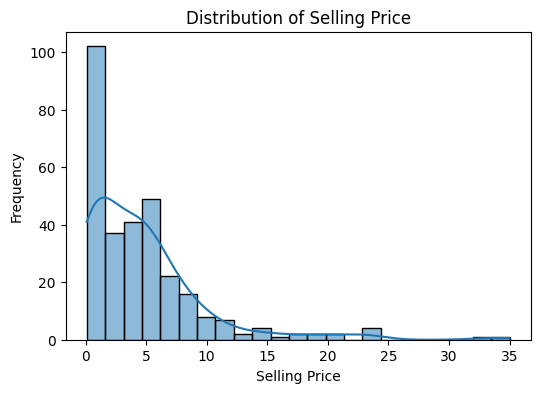

In [49]:
plt.figure(figsize=(6,4))
sns.histplot(df['Selling_Price'], kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()


#### Insight:
Most used cars are sold in the low to mid price range.

Correlation Analysis

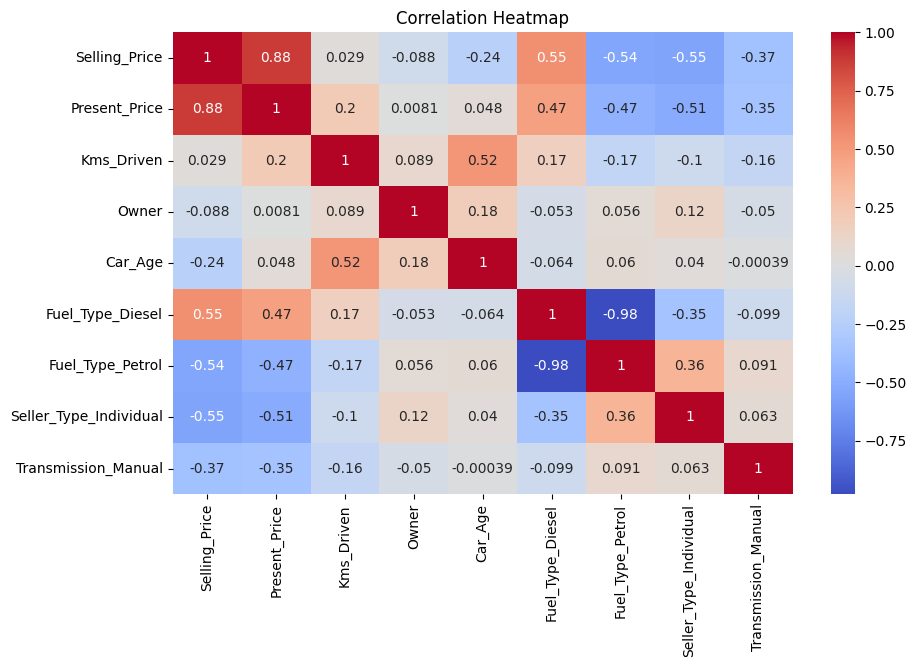

In [50]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


#### Insight:
Present_Price and Car_Age show strong influence on Selling_Price.

Selling Price vs Car Age

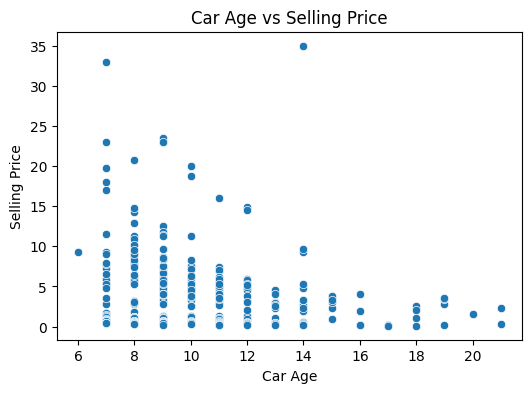

In [51]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Car_Age'], y=df['Selling_Price'])
plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.show()


#### Insight:
Older cars tend to have lower selling prices due to depreciation.

## Feature and Target Separation

In [52]:
# Define features and target variable
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Shape: (301, 8)
Target Shape: (301,)


## Train-Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (240, 8)
Testing Data Shape: (61, 8)


## Model Building using Linear Regression

Linear Regression is selected because it is simple, interpretable, and suitable for price prediction problems.
This helps in explaining how each feature affects the car price, making it useful for business decision-making.

In [54]:
# Create machine learning pipeline
model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train the model
model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

## Model Evaluation

The model is evaluated using standard regression metrics to measure prediction performance.

In [55]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R2 Score:", round(r2, 2))


Model Evaluation Results
Mean Absolute Error (MAE): 1.22
Root Mean Squared Error (RMSE): 1.87
R2 Score: 0.85


#### Interpretation:

*  Lower MAE and RMSE indicate better prediction accuracy





* R² Score shows how well the model explains price variation

## Actual vs Predicted Price Visualization

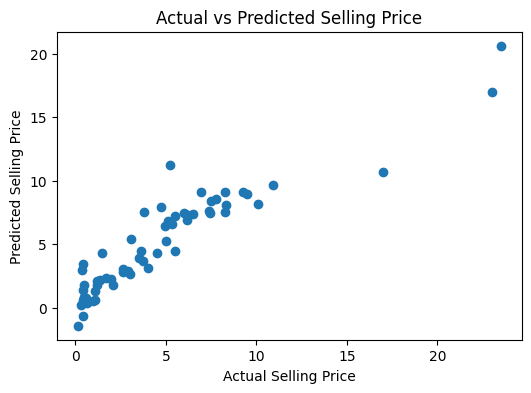

In [56]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()


#### Insight:
The predicted values are reasonably close to actual prices, indicating that the model performs well on unseen data.

## Business Impact of the Project

This project provides a data-driven pricing support system for used car dealers and resellers.
Key business benefits include:

Accurate price estimation

Reduced financial losses due to incorrect pricing

Faster decision-making using predictive insights

Reduced manual data cleaning through structured preprocessing workflow

Instead of relying on guesswork, dealers can use this model to set competitive and realistic car prices.

## Business Dashboard and Visualization (Power BI)

To make the project more business-oriented, I developed an interactive Power BI dashboard based on the cleaned dataset and model insights.

The dashboard helps stakeholders such as used car dealers and resellers to understand pricing patterns and key factors affecting car prices.

Key Dashboard Features:

* Selling Price analysis by Fuel Type

* Price vs Car Age trend analysis

* Transmission-wise price comparison

* Interactive filters for better decision-making

This integration bridges the gap between Machine Learning and Business Intelligence, allowing non-technical users to make data-driven pricing decisions.

## Conclusion

In this project, an end-to-end machine learning workflow was developed to predict used car prices using Linear Regression.
A structured preprocessing approach, feature engineering, and model evaluation were implemented to create a clean and interpretable solution.

The project focuses on solving a real business problem while maintaining simplicity, scalability, and clarity, making it suitable for real-world data analyst and entry-level data science applications.

## User Input Price Prediction (Business Use Case)

To make this project more practical, I added a user input prediction feature.

Using this, dealers or resellers can enter car details like present price, kilometers driven, fuel type, transmission, owner, and car age to get an estimated selling price.

Instead of depending on guesswork or manual analysis, this makes the model more usable for real-world pricing decisions.


In [57]:
# User Input Prediction System (Business-Oriented Implementation)

def predict_car_price():
    print("Enter Car Details for Price Prediction")

    present_price = float(input("Enter Present Price (in lakhs): "))
    kms_driven = int(input("Enter Kilometers Driven: "))
    owner = int(input("Enter Number of Previous Owners (0/1/2/3): "))
    car_age = int(input("Enter Car Age (Years): "))

    fuel_type = input("Enter Fuel Type (Petrol/Diesel/CNG): ").strip().lower()
    seller_type = input("Enter Seller Type (Dealer/Individual): ").strip().lower()
    transmission = input("Enter Transmission (Manual/Automatic): ").strip().lower()

    # Creating input data in the same format as training features
    input_data = {
        'Present_Price': [present_price],
        'Kms_Driven': [kms_driven],
        'Owner': [owner],
        'Car_Age': [car_age],
        'Fuel_Type_Diesel': [1 if fuel_type == 'diesel' else 0],
        'Fuel_Type_Petrol': [1 if fuel_type == 'petrol' else 0],
        'Seller_Type_Individual': [1 if seller_type == 'individual' else 0],
        'Transmission_Manual': [1 if transmission == 'manual' else 0]
    }

    input_df = pd.DataFrame(input_data)

    # Prediction using trained pipeline model
    predicted_price = model.predict(input_df)

    print("\nEstimated Selling Price:", round(predicted_price[0], 2), "Lakhs")


# Run the prediction function
predict_car_price()


Enter Car Details for Price Prediction
Enter Present Price (in lakhs): 12
Enter Kilometers Driven: 3245
Enter Number of Previous Owners (0/1/2/3): 1
Enter Car Age (Years): 3
Enter Fuel Type (Petrol/Diesel/CNG): petrol
Enter Seller Type (Dealer/Individual): dealer
Enter Transmission (Manual/Automatic): manual

Estimated Selling Price: 8.41 Lakhs
